In [ ]:
#Install Libraries

In [7]:
!pip install pandas scikit-image opencv-python

In [ ]:
#Imports

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from skimage.transform import resize

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

2026-03-02 10:46:04.390257: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-02 10:46:04.418780: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-02 10:46:04.418826: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-02 10:46:04.436597: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 10:46:05.609276: W tensorflow/com

In [ ]:
#Dataset Paths

In [2]:
DATASET_PATH = "dataset/Dataset for Fetus Framework"

TRAIN_STD = DATASET_PATH + "/Set1-Training&Validation Sets CNN/Standard"
TRAIN_ANN_STD = DATASET_PATH + "/Set2-Training&Validation Sets ANN Scoring system/Standard"
TRAIN_ANN_NON = DATASET_PATH + "/Set2-Training&Validation Sets ANN Scoring system/Non-standard"

INTERNAL_TEST = DATASET_PATH + "/Internal Test Set"
EXTERNAL_TEST = DATASET_PATH + "/External Test Set"

EXCEL_FILE = "dataset/ObjectDetection.xlsx"

In [ ]:
#Load Excel (Bounding Boxes)

In [3]:
df = pd.read_excel(EXCEL_FILE)

# keep only NT rows
nt_df = df[df["structure"] == "NT"]

nt_df.head()

,fname,structure,h_min,w_min,h_max,w_max
6,168.png,NT,385,257,418,464
16,169.png,NT,372,126,428,371
20,170.png,NT,376,12,416,478
30,171.png,NT,359,173,389,529
37,172.png,NT,375,293,399,380


In [ ]:
#Collect Image Paths

In [4]:
def get_image_paths(folder):

    paths = []

    if not os.path.exists(folder):
        return paths

    for file in os.listdir(folder):

        if file.endswith(".png"):
            paths.append(os.path.join(folder,file))

    return paths


paths1 = get_image_paths(TRAIN_STD)
paths2 = get_image_paths(TRAIN_ANN_STD)
paths3 = get_image_paths(TRAIN_ANN_NON)

all_paths = paths1 + paths2 + paths3

print("Total images:",len(all_paths))

Total images: 1368


In [ ]:
#Train Validation Split

In [5]:
train_paths, val_paths = train_test_split(
    all_paths,
    test_size=0.2,
    random_state=42
)

print(len(train_paths),len(val_paths))

1094 274


In [ ]:
#Image + Mask Loader

In [6]:
def load_image_mask(path):

    file = os.path.basename(path)

    img = cv2.imread(path)

    h_original,w_original = img.shape[:2]

    img = cv2.resize(img,(256,256))
    img = img / 255.0

    mask = np.zeros((256,256,1),dtype=np.float32)

    row = nt_df[nt_df["fname"]==file]

    if len(row)>0:

        h_min = int(row.iloc[0]["h_min"])
        w_min = int(row.iloc[0]["w_min"])
        h_max = int(row.iloc[0]["h_max"])
        w_max = int(row.iloc[0]["w_max"])

        h_scale = 256/h_original
        w_scale = 256/w_original

        h_min = int(h_min*h_scale)
        h_max = int(h_max*h_scale)
        w_min = int(w_min*w_scale)
        w_max = int(w_max*w_scale)

        mask[h_min:h_max,w_min:w_max] = 1

    return img.astype(np.float32),mask

In [ ]:
#TensorFlow Dataset Parser

In [7]:
def parse_image(path):

    path = path.numpy().decode()

    img,mask = load_image_mask(path)

    return img,mask


def tf_parse(path):

    img,mask = tf.py_function(
        parse_image,
        [path],
        [tf.float32,tf.float32]
    )

    img.set_shape([256,256,3])
    mask.set_shape([256,256,1])

    return img,mask

In [ ]:
#Data Augmentation

In [8]:
def augment(image,mask):

    if tf.random.uniform(())>0.5:

        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(())>0.5:

        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    return image,mask

In [ ]:
#Dataset Pipeline

In [9]:
BATCH = 8

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(train_paths)
    .map(tf_parse,num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment,num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(200)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset
    .from_tensor_slices(val_paths)
    .map(tf_parse,num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

2026-03-02 10:46:13.418601: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [10]:
def dice_coef(y_true,y_pred):

    y_true = tf.reshape(y_true,[-1])
    y_pred = tf.reshape(y_pred,[-1])

    intersection = tf.reduce_sum(y_true*y_pred)

    return (2.*intersection+1)/(tf.reduce_sum(y_true)+tf.reduce_sum(y_pred)+1)


def dice_loss(y_true,y_pred):

    return 1-dice_coef(y_true,y_pred)


bce = tf.keras.losses.BinaryCrossentropy()


def combined_loss(y_true,y_pred):

    return bce(y_true,y_pred) + dice_loss(y_true,y_pred)

In [ ]:
#U-Net + CNN Model

In [11]:
def build_model():

    inputs = Input((256,256,3))

    base_model = tf.keras.applications.MobileNetV2(
        input_tensor=inputs,
        include_top=False,
        weights="imagenet"
    )

    s1 = base_model.get_layer("block_1_expand_relu").output
    s2 = base_model.get_layer("block_3_expand_relu").output
    s3 = base_model.get_layer("block_6_expand_relu").output
    s4 = base_model.get_layer("block_13_expand_relu").output

    bridge = base_model.get_layer("block_16_project").output

    d1 = Conv2DTranspose(512,2,strides=2,padding="same")(bridge)
    d1 = concatenate([d1,s4])
    d1 = Conv2D(512,3,padding="same",activation="relu")(d1)

    d2 = Conv2DTranspose(256,2,strides=2,padding="same")(d1)
    d2 = concatenate([d2,s3])
    d2 = Conv2D(256,3,padding="same",activation="relu")(d2)

    d3 = Conv2DTranspose(128,2,strides=2,padding="same")(d2)
    d3 = concatenate([d3,s2])
    d3 = Conv2D(128,3,padding="same",activation="relu")(d3)

    d4 = Conv2DTranspose(64,2,strides=2,padding="same")(d3)
    d4 = concatenate([d4,s1])
    d4 = Conv2D(64,3,padding="same",activation="relu")(d4)

    d5 = Conv2DTranspose(32,2,strides=2,padding="same")(d4)
    d5 = Conv2D(32,3,padding="same",activation="relu")(d5)

    outputs = Conv2D(1,1,activation="sigmoid")(d5)

    return Model(inputs,outputs)

In [12]:
model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=["accuracy",dice_coef]
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 128, 128, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 128, 128, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 128, 128, 32)         0         ['bn_Conv1[0][0]']        

In [ ]:
callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        save_best_only=True,
        monitor="val_loss"
    ),

    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(

    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
137/137 [==============================] - 1036s 7s/step - loss: 0.7502 - accuracy: 0.9745 - dice_coef: 0.3527 - val_loss: 1.0979 - val_accuracy: 0.9743 - val_dice_coef: 0.1047
Epoch 2/20
137/137 [==============================] - 984s 7s/step - loss: 0.3885 - accuracy: 0.9840 - dice_coef: 0.6700 - val_loss: 0.6950 - val_accuracy: 0.9793 - val_dice_coef: 0.3997
Epoch 3/20
137/137 [==============================] - 975s 7s/step - loss: 0.3413 - accuracy: 0.9861 - dice_coef: 0.7097 - val_loss: 0.7204 - val_accuracy: 0.9791 - val_dice_coef: 0.3846
Epoch 4/20
137/137 [==============================] - 977s 7s/step - loss: 0.3208 - accuracy: 0.9872 - dice_coef: 0.7268 - val_loss: 0.6548 - val_accuracy: 0.9802 - val_dice_coef: 0.4322
Epoch 5/20
137/137 [==============================] - 980s 7s/step - loss: 0.2912 - accuracy: 0.9884 - dice_coef: 0.7521 - val_loss: 0.4343 - val_accuracy: 0.9844 - val_dice_coef: 0.6156
Epoch 6/20
137/137 [==============================] - 1005s 7s/s

In [16]:
evaluation = model.evaluate(val_dataset)
print(f"Loss: {evaluation[0]}")
print(f"Accuracy: {evaluation[1]}") 
print(f"Dice Coefficient: {evaluation[2]}")

35/35 [==============================] - 49s 1s/step - loss: 0.3203 - accuracy: 0.9870 - dice_coef: 0.7364
Loss: 0.32027849555015564
Accuracy: 0.9869921803474426
Dice Coefficient: 0.7364213466644287


In [70]:
def predict_nt(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(img,(256,256))
    img = img/255.0

    img = np.expand_dims(img,0)

    pred = model.predict(img)[0,:,:,0]

    mask = pred > 0.35

    coords = np.where(mask)

    if len(coords[0])==0:
        return 0

    thickness = coords[0].max() - coords[0].min()

    return thickness

In [71]:
def classify_risk(image_path):
    nt_pixels = predict_nt(image_path)
    
    pixel_to_mm = 0.1   # adjust if needed
    
    nt_mm = nt_pixels * pixel_to_mm
    
    if nt_mm < 3.5:
        risk = "LOW RISK"
    else:
        risk = "HIGH RISK"
    
    print("NT pixels:", nt_pixels)
    print("NT thickness (mm):", nt_mm)
    print("Risk:", risk)
    return nt_mm, risk

In [72]:
#Test Prediction

In [73]:
image_path = "dataset/Dataset for Fetus Framework/External Test Set/Standard/1426.png"

classify_risk(image_path)

1/1 [==============================] - 0s 218ms/step
NT pixels: 7
NT thickness (mm): 0.7000000000000001
Risk: LOW RISK


(0.7000000000000001, 'LOW RISK')

In [76]:
def show_plot(image_path):

    img = cv2.imread(image_path)

    img_res = cv2.resize(img,(256,256))
    img_norm = img_res / 255.0

    img_input = np.expand_dims(img_norm,0)

    pred = model.predict(img_input)[0,:,:,0]

    mask = pred > 0.35

    # calculate NT thickness
    coords = np.where(mask)

    if len(coords[0]) == 0:
        nt_pixels = 0
    else:
        nt_pixels = coords[0].max() - coords[0].min()

    pixel_to_mm = 0.1
    nt_mm = nt_pixels * pixel_to_mm

    if nt_mm < 3.5:
        risk = "LOW RISK"
    else:
        risk = "HIGH RISK"

    print("NT pixels:", nt_pixels)
    print("NT thickness (mm):", nt_mm)
    print("Risk:", risk)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Ultrasound")
    plt.imshow(img_res[:,:,::-1])
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Predicted NT Mask")
    plt.imshow(mask,cmap="gray")
    plt.axis("off")

    overlay = img_res.copy()
    overlay[mask] = [255,0,0]
    
    plt.subplot(1,3,3)
    plt.title(f"Overlay - {risk}")
    plt.imshow(overlay[:,:,::-1])
    plt.axis("off")

    plt.show()

1/1 [==============================] - 0s 210ms/step
NT pixels: 14
NT thickness (mm): 1.4000000000000001
Risk: LOW RISK


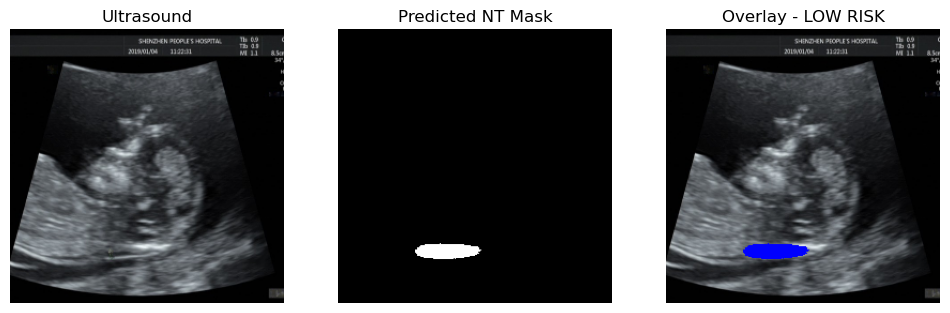

1/1 [==============================] - 0s 191ms/step
NT pixels: 16
NT thickness (mm): 1.6
Risk: LOW RISK


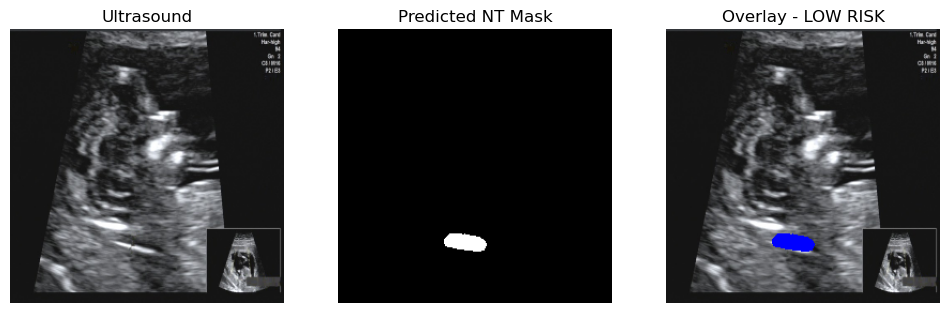

1/1 [==============================] - 0s 227ms/step
NT pixels: 52
NT thickness (mm): 5.2
Risk: HIGH RISK


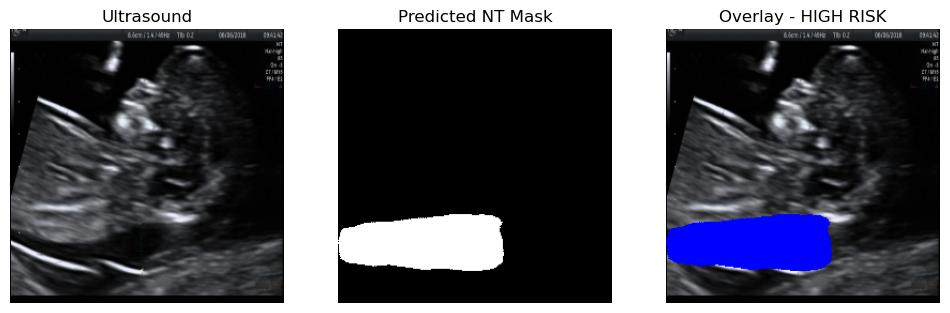

1/1 [==============================] - 0s 209ms/step
NT pixels: 23
NT thickness (mm): 2.3000000000000003
Risk: LOW RISK


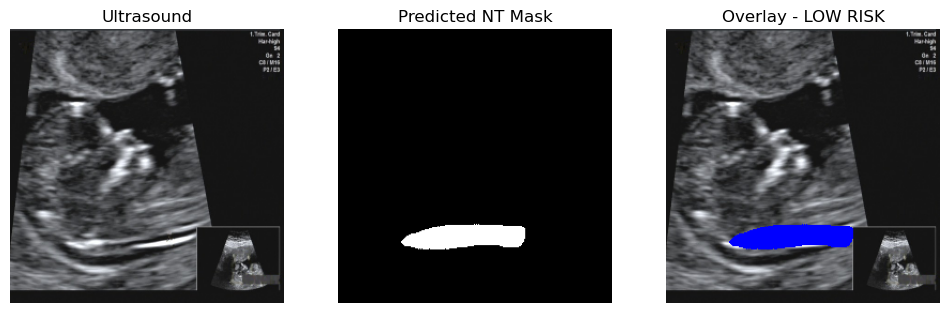

1/1 [==============================] - 0s 194ms/step
NT pixels: 21
NT thickness (mm): 2.1
Risk: LOW RISK


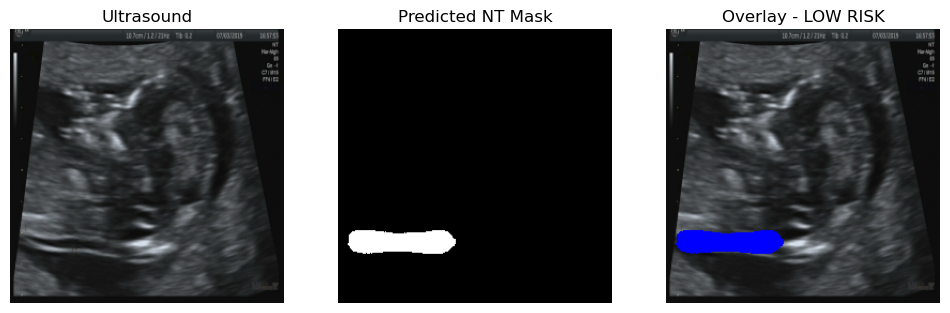

1/1 [==============================] - 0s 192ms/step
NT pixels: 30
NT thickness (mm): 3.0
Risk: LOW RISK


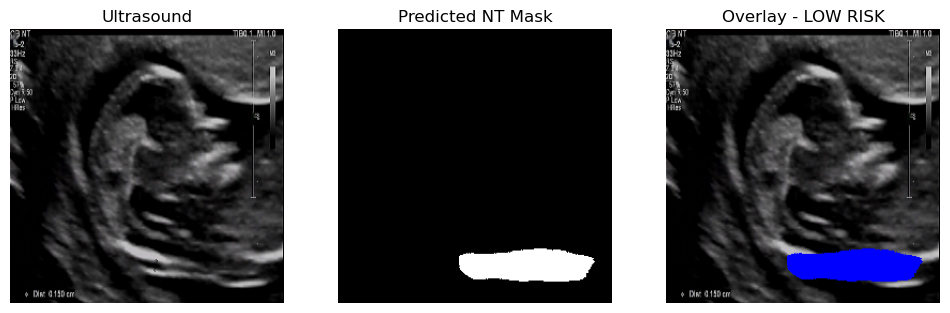

1/1 [==============================] - 0s 187ms/step
NT pixels: 36
NT thickness (mm): 3.6
Risk: HIGH RISK


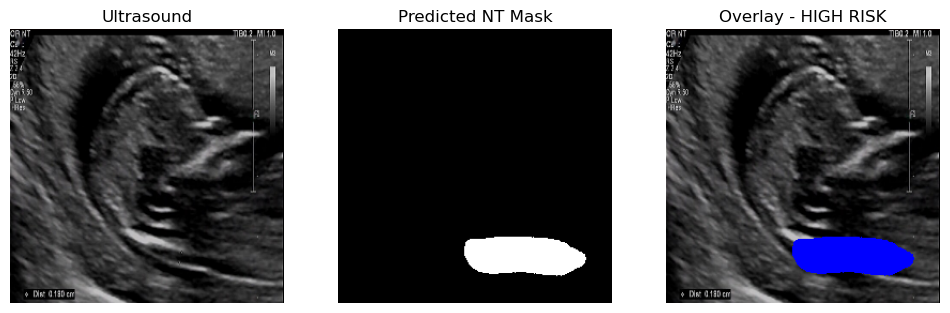

1/1 [==============================] - 0s 190ms/step
NT pixels: 31
NT thickness (mm): 3.1
Risk: LOW RISK


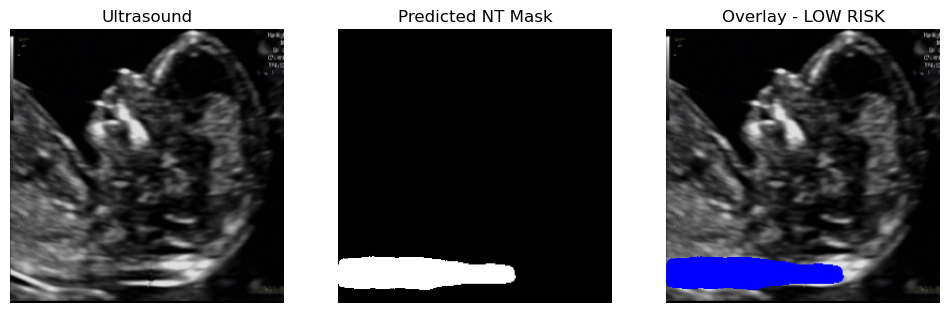

1/1 [==============================] - 0s 255ms/step
NT pixels: 45
NT thickness (mm): 4.5
Risk: HIGH RISK


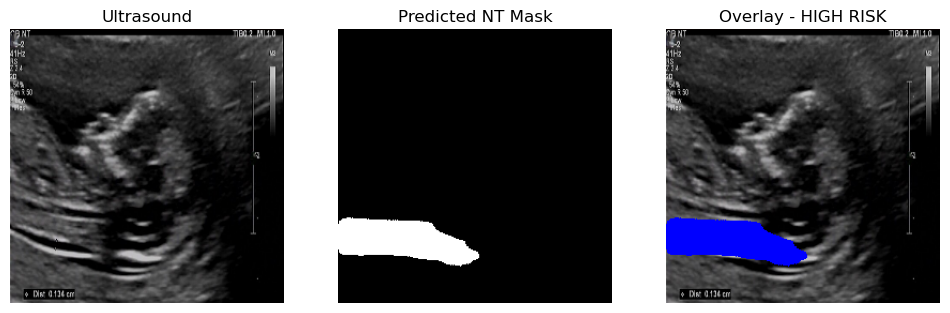

1/1 [==============================] - 0s 383ms/step
NT pixels: 27
NT thickness (mm): 2.7
Risk: LOW RISK


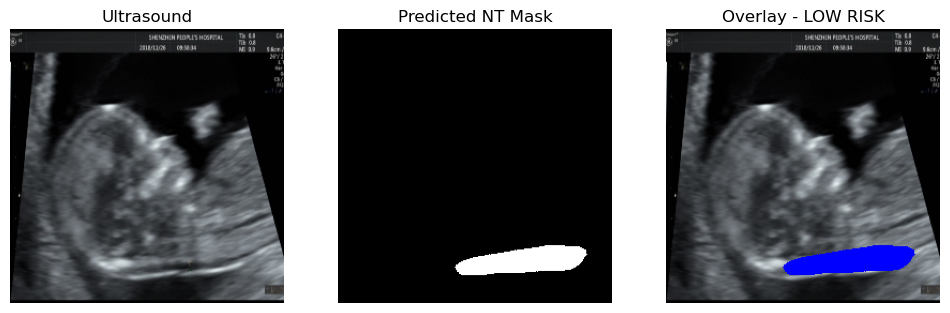

In [80]:
import os

folder2 = "test data"

for img_name in range(1,11):

    path = os.path.join(folder2,str(img_name)+".png")
    show_plot(path)